# Creating Song Cohorts

Clustering Spotify songs using audio features and building a simple song recommendation system.

In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

import joblib
import warnings

warnings.filterwarnings("ignore")

In [39]:
df = pd.read_csv("../data/spotify_tracks.csv")
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [40]:
# Dataset Shape
print(df.shape)
#Columns Names
print(df.columns)

(114000, 21)
Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='str')


In [41]:
#Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

## 
Observation:
The dataset contains Spotify songs with audio features such as energy, danceability, tempo, and popularity.

In [42]:
#Summary Statistics
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [43]:
#Missing Values
df.isnull().sum

<bound method DataFrame.sum of         Unnamed: 0  track_id  artists  album_name  track_name  popularity  \
0            False     False    False       False       False       False   
1            False     False    False       False       False       False   
2            False     False    False       False       False       False   
3            False     False    False       False       False       False   
4            False     False    False       False       False       False   
...            ...       ...      ...         ...         ...         ...   
113995       False     False    False       False       False       False   
113996       False     False    False       False       False       False   
113997       False     False    False       False       False       False   
113998       False     False    False       False       False       False   
113999       False     False    False       False       False       False   

        duration_ms  explicit  danceability 

## 
Observation:
Only a few columns contain missing values which will be handled during preprocessing.

In [44]:
#Duplicate Songs
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


## Data Cleaning

In [45]:
#Remove Duplicates
df = df.drop_duplicates()

In [46]:
#Remove Missing Values
df = df.dropna()

In [47]:
#Drop Unnecessary Columns
df = df.drop(
    columns=[
        "Unnamed: 0",
        "track_id",
        "album_name"
    ]
)

In [48]:
#Check Dataset
df.head()

,artists,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Gen Hoshino,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,Ben Woodward,Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,Ingrid Michaelson;ZAYN,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,Kina Grannis,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,Chord Overstreet,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [49]:
#Final shape
print(df.shape)

(113999, 18)


## 
Observation:
Unnecessary columns, duplicate records, and missing values were removed before feature selection.

## EDA

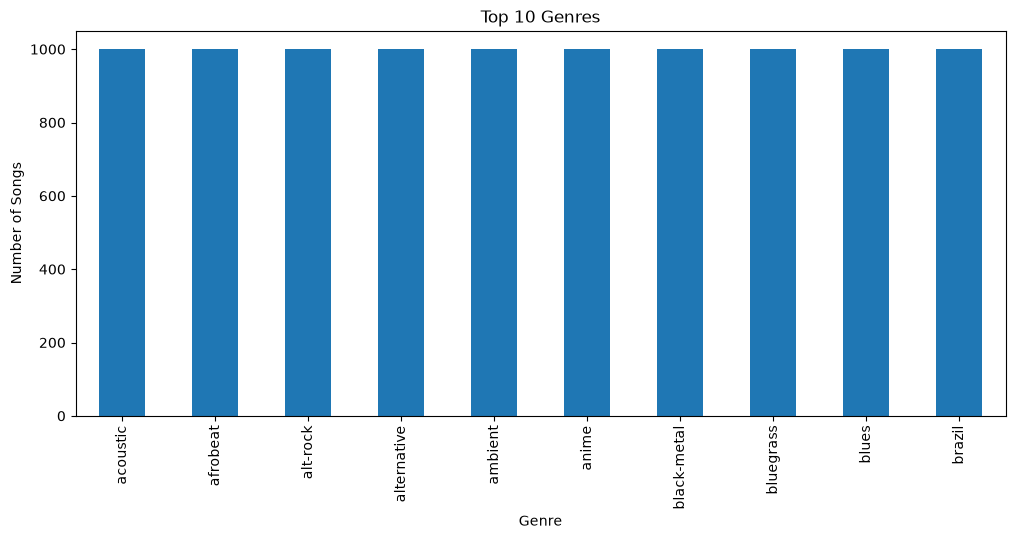

In [50]:
#Genre Distribution
plt.figure(figsize=(12,5))
df["track_genre"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Songs")
plt.show()

## 
Observation:
The dataset contains songs from multiple genres, providing diverse musical characteristics for clustering.

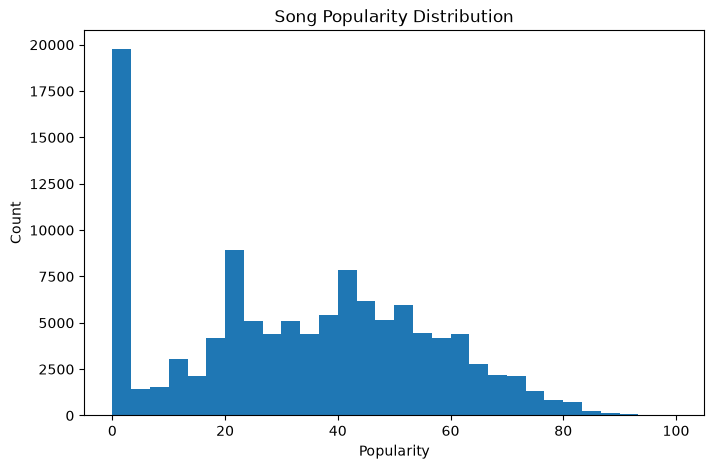

In [51]:
#Popularity Distribution
plt.figure(figsize=(8,5))
plt.hist(df["popularity"], bins=30)
plt.title("Song Popularity Distribution")
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.show()

## 
Observation:
Song popularity varies widely, with many tracks having moderate popularity scores.

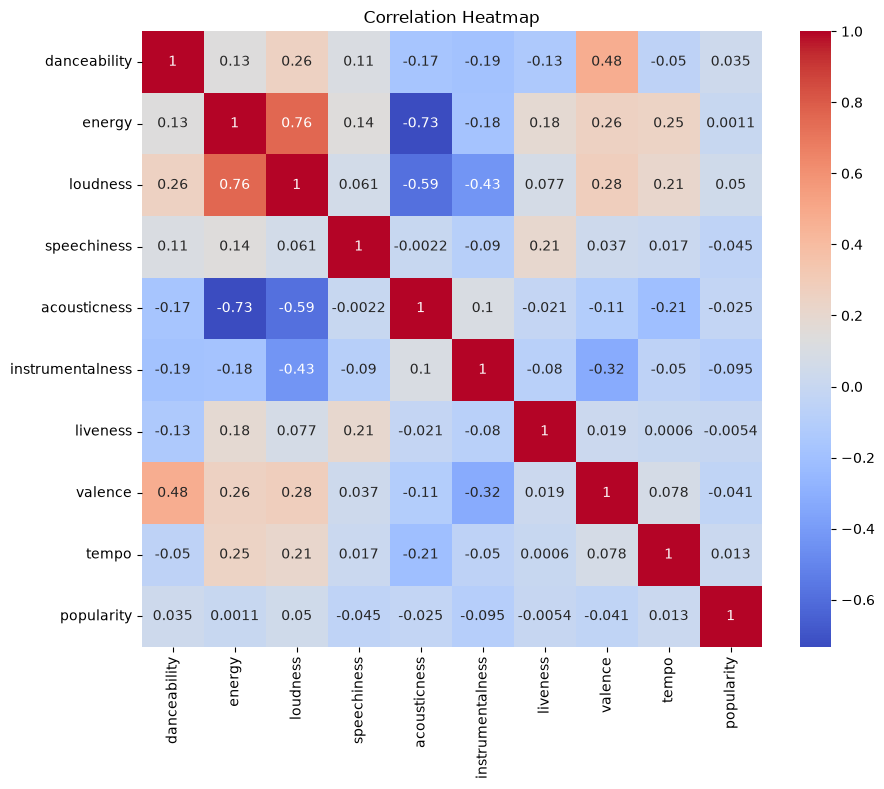

In [53]:
#Correlation Heatmap
audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "popularity"
]
plt.figure(figsize=(10,8))
sns.heatmap(
    df[audio_features].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

## 
Observation:
Some audio features are positively correlated, while others capture unique aspects of a song's characteristics.

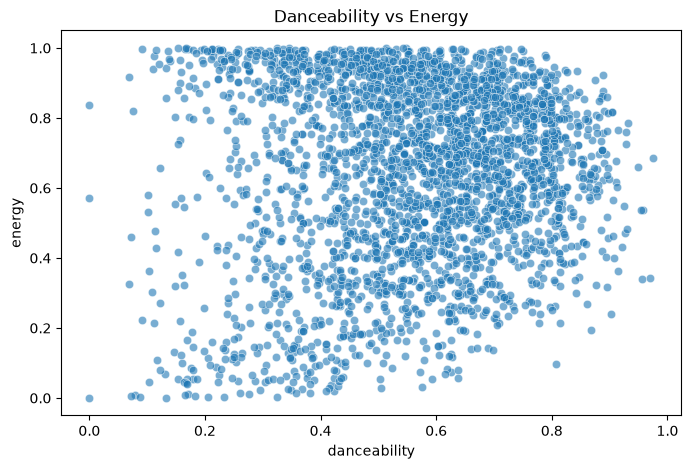

In [54]:
# Danceability vs Energy
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df.sample(3000, random_state=42),
    x="danceability",
    y="energy",
    alpha=0.6
)
plt.title("Danceability vs Energy")
plt.show()

## 
Observation:
Songs exhibit varying combinations of danceability and energy, suggesting natural groupings suitable for clustering.

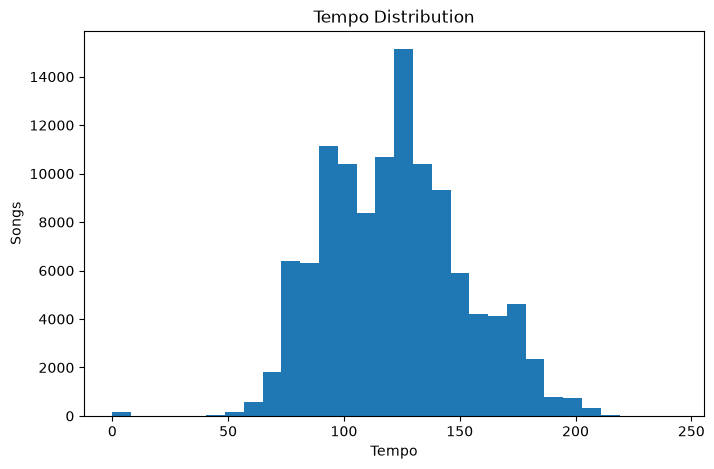

In [55]:
#Tempo Distribution
plt.figure(figsize=(8,5))
plt.hist(df["tempo"], bins=30)
plt.title("Tempo Distribution")
plt.xlabel("Tempo")
plt.ylabel("Songs")
plt.show()

## 
Observation:
Most songs fall within a moderate tempo range, while extremely slow or fast tracks are less common.

## Feature Selection & Scaling
The dataset has many columns like: track_name, artists, genre
(These are text columns).
Machine Learning clustering algorithms only work with numerical features, so we'll use Spotify's audio features.

In [58]:
#Select audio features
features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms",
    "popularity"
]
X = df[features]
X.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,popularity
0,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917,230666,73
1,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489,149610,55
2,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332,210826,57
3,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740,201933,71
4,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949,198853,82


## 
Observation:
Only numerical audio features are selected because they represent the musical characteristics required for clustering.

In [59]:
#Standard Scalling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

(113999, 11)


## 
Observation:
Feature scaling ensures that all audio features contribute equally during clustering.

## K-Means Clustering
K-Means groups songs with similar musical properties.
Songs inside the same cluster should sound more alike.

In [60]:
#Elbow Method
from sklearn.cluster import KMeans
wcss = []
for i in range(2,11):

    model = KMeans(
        n_clusters=i,
        random_state=42
    )
    model.fit(X_scaled)
    wcss.append(model.inertia_)

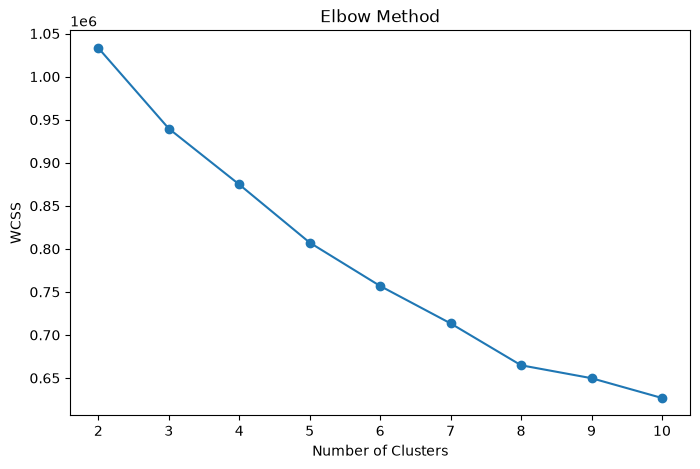

In [61]:
#Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

## 
Observation:
The elbow curve suggests an optimal number of clusters. We will use five clusters for song segmentation.

In [62]:
# Train K-Means
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)
df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)
df.head()

,artists,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,KMeans_Cluster
0,Gen Hoshino,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,1
1,Ben Woodward,Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,3
2,Ingrid Michaelson;ZAYN,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,3
3,Kina Grannis,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,3
4,Chord Overstreet,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,3


In [63]:
# Cluster Distribution
df["KMeans_Cluster"].value_counts()

KMeans_Cluster
1    41474
0    31154
3    24727
4     8408
2     8236
Name: count, dtype: int64

In [64]:
# Cluster Summary
cluster_summary = df.groupby("KMeans_Cluster")[features].mean()
cluster_summary

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,popularity
KMeans_Cluster,,,,,,,,,,,
0,0.484495,0.805375,-6.112393,0.077546,0.062916,0.249152,0.190054,0.312889,136.072288,264493.468094,34.645663
1,0.690358,0.737316,-6.264977,0.091668,0.186817,0.045407,0.167694,0.687677,120.738643,209580.975889,31.901191
2,0.359307,0.188948,-20.586715,0.052181,0.833466,0.770039,0.162818,0.189487,103.833941,221340.013235,27.603570
3,0.544334,0.388527,-10.456639,0.055693,0.664220,0.051445,0.158409,0.405142,113.409125,212976.604238,35.191936
4,0.531618,0.747343,-7.509440,0.193349,0.345186,0.063063,0.738714,0.499053,121.141858,234764.951713,34.400333


## 
Observation:
Each cluster groups songs with similar audio characteristics such as energy, danceability, tempo, and popularity.

## DBSCAN Clustering
DBSCAN automatically detects clusters, identifies outliers, does not require specifying the number of clusters.

In [66]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(
    eps=1.2,
    min_samples=10
)
df["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

In [69]:
df["DBSCAN_Cluster"].value_counts()

DBSCAN_Cluster
 0     100733
-1      12337
 10       516
 28        45
 21        30
 20        26
 24        21
 2         20
 23        18
 25        18
 6         16
 11        15
 15        15
 4         14
 5         14
 8         13
 12        13
 26        13
 14        12
 16        12
 27        11
 29        11
 1         10
 7         10
 13        10
 17        10
 3          9
 19         8
 22         7
 18         6
 9          6
Name: count, dtype: int64

## 
Observation:
DBSCAN groups dense regions of similar songs while identifying outliers that do not belong to any cluster.

## PCA Visualization
We have 11 features, PCA converts them into Principal Component 1 and Principal Component 2. so we can visualize the clusters.

In [70]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

In [71]:
plot_df = pd.DataFrame({
    "PCA1": components[:,0],
    "PCA2": components[:,1],
    "Cluster": df["KMeans_Cluster"]
})
plot_df.head()

,PCA1,PCA2,Cluster
0,0.697400,1.061899,1
1,-3.283506,1.337895,3
2,-1.349490,-0.132272,3
3,-3.318170,-0.282420,3
4,-0.912603,0.359498,3


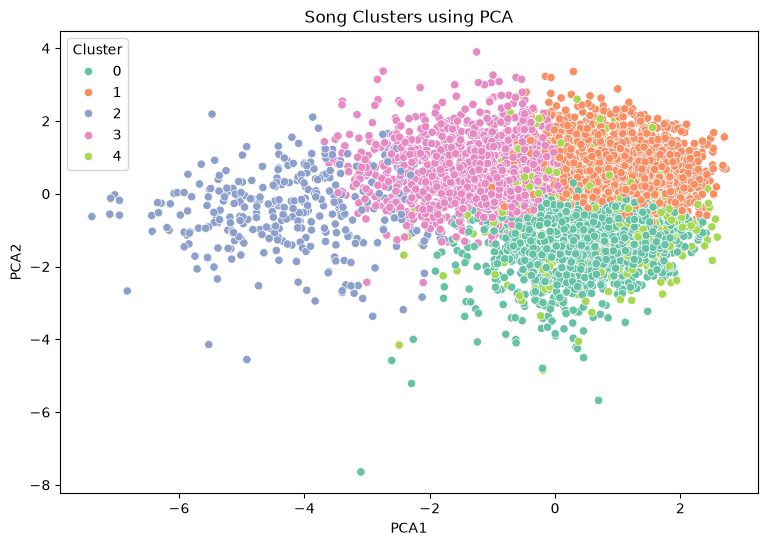

In [72]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=plot_df.sample(5000, random_state=42),
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set2"
)
plt.title("Song Clusters using PCA")
plt.show()

## 
Observation:
PCA reduces the high-dimensional audio features into two dimensions, making the song clusters easier to visualize.

In [73]:
#Song Recommendation System
def recommend_songs(song_name, dataframe, n=5):

    song = dataframe[
        dataframe["track_name"].str.lower() == song_name.lower()
    ]

    if song.empty:
        return "Song not found."

    cluster = song.iloc[0]["KMeans_Cluster"]

    recommendations = dataframe[
        dataframe["KMeans_Cluster"] == cluster
    ]

    recommendations = recommendations[
        recommendations["track_name"].str.lower() != song_name.lower()
    ]

    return recommendations[
        ["track_name","artists","track_genre","popularity"]
    ].head(n)

In [74]:
recommend_songs("Believer", df)

,track_name,artists,track_genre,popularity
40,The Haves,Eddie Vedder,acoustic,0
44,"Speak Your Mind (From the Netflix Series ""We T...",Brandi Carlile,acoustic,0
52,Pieces,Andrew Belle,acoustic,60
55,The Enemy,Andrew Belle,acoustic,62
61,Sky's Still Blue,Andrew Belle,acoustic,62


In [75]:
df["track_name"].sample(20, random_state=42)

113186                                        No Other Name
42819                                        Failed Organum
59311                                 Save the Trees, Pt. 1
90417                                It's Only Make Believe
61000                                                 月の大きさ
96815                                Jah Jah Revolta, Pt. 2
18939                             Please Stop Communicating
72760                                     A Form of Protest
25788                                I'm Ready - Radio Edit
87169                   Proibida Pra Mim (Grazon) - Ao Vivo
19261     I'll Be Home For Christmas - From The Kacey Mu...
62735                                                 時間がない
108051                                                  Sur
91831                                            Zombie Zoo
115                                 In Case You Didn’t Know
87994                                       O Sopro do Fole
96569                     Vi Mamãe Oxum 

## 
Observation:
Songs belonging to the same cluster share similar musical characteristics, enabling a simple content-based recommendation system.

In [ ]:
#saving outputs
import os
import joblib

os.makedirs("../outputs", exist_ok=True)
os.makedirs("../models", exist_ok=True)

df.to_csv(
    "../outputs/clustered_songs.csv",
    index=False
)
cluster_summary.to_csv(
    "../outputs/cluster_summary.csv"
)

joblib.dump(
    kmeans,
    "../models/song_cluster_model.pkl"
)

print("Project Completed Successfully!")

Project Completed Successfully!
